# Importing Libraries

In [1]:
## Import modules
import os, sys
import numpy as np
import geopandas as gpd
import cftime
import gc
import shapely
import json
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt

# Add the directory containing 'cmct' to the Python path
# Navigate two levels up to reach main CmCt dir
cmct_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# Initialising Logger
import logging

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Import utilities for this comparison
sys.path.insert(0, cmct_dir)
from cmct.time_utils import *
from cmct.calving import *
from cmct.calving_modules.interpolation import *
from cmct.calving_modules.residual_calculation import *
# from cmct.calving_modules.json_to_netcdf import *
# from cmct.shapefile_utils import *

# Force initial garbage collection
gc.collect()

20

In [2]:
# Reload modules to pick up any changes to imports
import importlib
import cmct.calving
import cmct.calving_modules.residual_calculation
import cmct.calving_modules.plotting_utils
importlib.reload(cmct.calving)
importlib.reload(cmct.calving_modules.residual_calculation)

# Re-import to ensure functions are available
from cmct.calving import *

# CONFIGURATION

In [ ]:
# Observation Dataset
# Ice sheet
loc = "GIS"  # 'GIS' or 'AIS'

# Set the observation data dir path
obs_filename = cmct_dir + "/data/calving/observed_icemask_ismip_annual.nc"

# To use aggregation functions for basin
basin_aggregation = True  # IMPORTANT

basin_filename = cmct_dir + "/bin/Calving/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp"

# Set the Model Data dir path
# model_filename = cmct_dir + "/test/calving/ensemble/sftgif_B001_hist.nc"
model_filename = cmct_dir + "/test/calving/sftgif_GIS_JPL_ISSM_historical.nc"

# Set time range for comparison
start_year = 2007
end_year = 2010

# List of basins (ex ["NW", "NE"]) to compare if all -> "all", if none -> False
# If you do not know which basins are in the model, you can put "auto"
# NOTE: Align this list with the basins in the model.
basin_list = ["NW"]

# Output filetype and filename
filetype = "netcdf"  # netcdf or json or None
filename = "calving_comparison"

# Optional Configurations
interpolation_method = "slinear"  # 'nearest', 'linear', 'cubic'
accuracy_calculation_method = "mean"  # 'mean', 'RMS',

colors = {
    "CW": "blue",
    "NE": "red",
    "SE": "green",
    "SW": "orange",
    "NO": "purple",
    "NW": "brown",
}


# Loading all data files

In [4]:
# Check if observation file exist
if not os.path.exists(obs_filename):
    raise FileNotFoundError(f"Observation file not found: {obs_filename}")

# # Check if model file exist
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")



if basin_aggregation and not os.path.exists(basin_filename):
    raise FileNotFoundError(f"Basin shapefile not found: {basin_filename}")
    # Load basin shapes

print(basin_filename)
basins, basin_list = load_basins(basin_filename, basin_list)

print(obs_filename)
gsfc = load_gsfc_calving(obs_filename, basins)

print(model_filename)
model_res = load_model_calving(model_filename)

/Users/aditya_pachpande/Documents/GitHub/CmCt/bin/Calving/GRE_Basins_IMBIE2_v1.3/GRE_Basins_IMBIE2_v1.3.shp
/Users/aditya_pachpande/Documents/GitHub/CmCt/data/calving/observed_icemask_ismip_annual.nc
/Users/aditya_pachpande/Documents/GitHub/CmCt/test/calving/sftgif_GIS_JPL_ISSM_historical.nc


## Handelling Time Consistency

In [5]:
# Simplifying date data type
gsfc.ds["time"] = standardising_time_var(gsfc.time)
model_res.ds["time"] = standardising_time_var(model_res.time)

# Handelling Time Range
checking_calving_daterange(gsfc.time.values, model_res.time.values, start_year, end_year)


The selected dates 2007 to 2010 are within the overlapping data range.


# Interpolation

In [6]:
interpolater = Interpolater(model_res, gsfc)
model_res.ds = interpolater.interpolate()
print(f"\nResampled data shape: {model_res.ds.dims}")

2025-07-16 10:51:14,653 - INFO - Input x coordinates: [-720000. -715000. -710000. -705000. -700000. -695000. -690000. -685000.
 -680000. -675000. -670000. -665000. -660000. -655000. -650000. -645000.
 -640000. -635000. -630000. -625000. -620000. -615000. -610000. -605000.
 -600000. -595000. -590000. -585000. -580000. -575000. -570000. -565000.
 -560000. -555000. -550000. -545000. -540000. -535000. -530000. -525000.
 -520000. -515000. -510000. -505000. -500000. -495000. -490000. -485000.
 -480000. -475000. -470000. -465000. -460000. -455000. -450000. -445000.
 -440000. -435000. -430000. -425000. -420000. -415000. -410000. -405000.
 -400000. -395000. -390000. -385000. -380000. -375000. -370000. -365000.
 -360000. -355000. -350000. -345000. -340000. -335000. -330000. -325000.
 -320000. -315000. -310000. -305000. -300000. -295000. -290000. -285000.
 -280000. -275000. -270000. -265000. -260000. -255000. -250000. -245000.
 -240000. -235000. -230000. -225000. -220000. -215000. -210000. -20500


Resampled data shape: FrozenMappingWarningOnValuesAccess({'y': 2880, 'x': 1680, 'nv4': 4, 'time': 36})


# Comparison and Residual Calculation 

In [7]:
print(type(basins))
years = np.arange(start_year, end_year + 1)
residuals = create_calving_dataset(gsfc, model_res, years, basins)



2025-07-16 10:51:18,976 - INFO - Starting optimized calving dataset creation...
2025-07-16 10:51:18,983 - INFO - Transformed basin CW: 1211 points
2025-07-16 10:51:18,992 - INFO - Transformed basin NE: 6780 points
2025-07-16 10:51:19,001 - INFO - Transformed basin SE: 15619 points
2025-07-16 10:51:19,004 - INFO - Transformed basin SW: 4063 points
2025-07-16 10:51:19,007 - INFO - Transformed basin NO: 4016 points
2025-07-16 10:51:19,010 - INFO - Transformed basin NW: 4986 points
2025-07-16 10:51:19,013 - INFO - Grid dimensions: 2880 x 1680
2025-07-16 10:51:19,113 - INFO - Computing residuals...


<class 'dict'>


2025-07-16 10:51:19,435 - INFO - Computing statistics...
2025-07-16 10:51:19,541 - INFO - Creating basin assignments...
2025-07-16 10:51:19,541 - INFO - Data coordinates: X=[-719500.0, 959500.0], Y=[-3449500.0, -570500.0]
2025-07-16 10:51:19,541 - INFO - Basin polygon coordinates: X=[-607915.8, 839103.9], Y=[-3309066.0, -789966.1]
2025-07-16 10:51:40,969 - INFO - Basin assignment complete. Unique basin IDs: [-1  0  1  2  3  4  5]
2025-07-16 10:51:40,971 - INFO -   Unassigned points: 3112422
2025-07-16 10:51:40,973 - INFO -   Basin 0 (CW): 232302 points
2025-07-16 10:51:40,975 - INFO -   Basin 1 (NE): 478030 points
2025-07-16 10:51:40,976 - INFO -   Basin 2 (SE): 294627 points
2025-07-16 10:51:40,978 - INFO -   Basin 3 (SW): 217562 points
2025-07-16 10:51:40,980 - INFO -   Basin 4 (NO): 232587 points
2025-07-16 10:51:40,981 - INFO -   Basin 5 (NW): 270870 points
2025-07-16 10:51:40,983 - INFO - Basin assignment rate: 1725978/4838400 (35.7%)
2025-07-16 10:51:40,989 - INFO - Optimized dat

In [8]:
residuals = load_residuals(residuals)


In [9]:
vars(residuals)


{'ds': <xarray.Dataset> Size: 310MB
 Dimensions:                 (time: 4, y: 2880, x: 1680, basin_id: 6)
 Coordinates:
   * time                    (time) int64 32B 2007 2008 2009 2010
   * x                       (x) float32 7kB -7.195e+05 -7.185e+05 ... 9.595e+05
   * y                       (y) float32 12kB -3.45e+06 -3.448e+06 ... -5.705e+05
     basin_names             (basin_id) <U2 48B 'CW' 'NE' 'SE' 'SW' 'NO' 'NW'
 Dimensions without coordinates: basin_id
 Data variables:
     residual                (time, y, x) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0
     basin                   (time, y, x) int32 77MB -1 -1 -1 -1 ... -1 -1 -1 -1
     gsfc_ice_mask           (time, y, x) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0
     model_ice_mask          (time, y, x) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0
     stats_avg_abs_residual  (time) float64 32B 0.02462 0.0246 0.0246 0.02462
     stats_rms_residual      (time) float64 32B 0.1319 0.1318 0.1319 0.1319
     stats_sum_residual      (time) float6

# Plot Generation

## Configuration
- residuals are required for plot generation

In [10]:
# Which year do you want plots for?
year = 2007

cmap = "ocean"  # Leave default to Ocean :)
aspect = "auto"

# Plot config
plt.figure(figsize=(10, 6))
# plt.cm.viridis.set_bad('lightblue')  # Set color for NaN values


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

(4, 2880, 1680)
Data shape for year 2007: (2880, 1680)
Showing all data (all basins)
Testing plot function...


<Figure size 640x480 with 0 Axes>

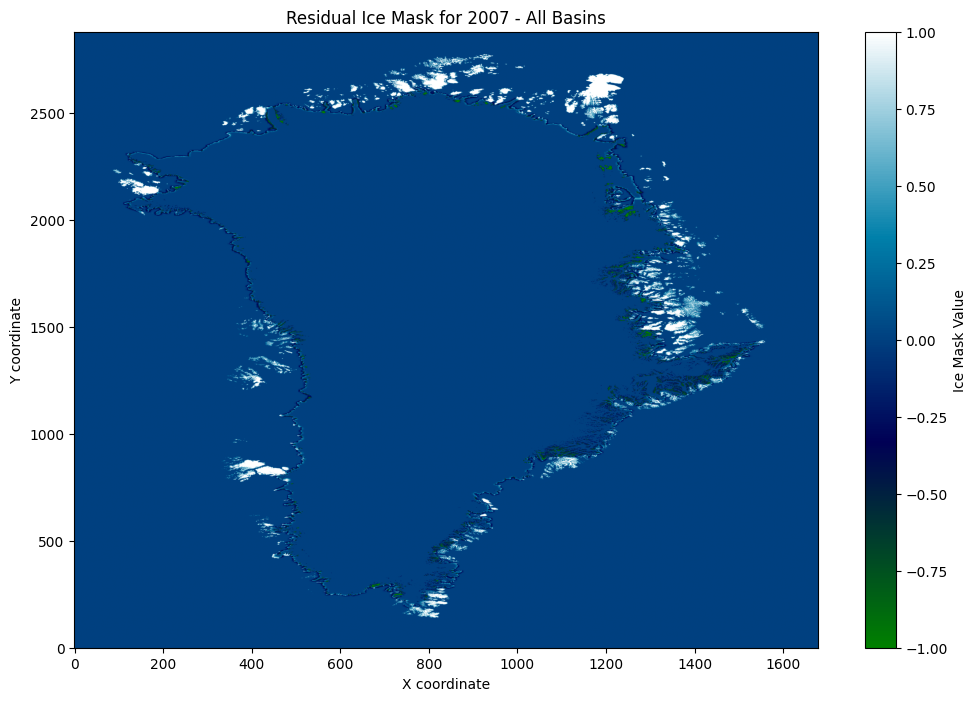


Interactive plotting:
Basin ID: -1 = All basins, 0-5 = Specific basin
  Basin ID 0: CW
  Basin ID 1: NE
  Basin ID 2: SE
  Basin ID 3: SW
  Basin ID 4: NO
  Basin ID 5: NW


interactive(children=(FloatSlider(value=2007.0, description='Year:', max=2010.0, min=2007.0, step=1.0), FloatS…

<function __main__.interactive_plot(year, basin_id)>

In [ ]:
print(residuals.ds.residual.values.shape)

basin_id = None
data = residuals.get_basin_data(year, basin_id)
rotated_data = np.rot90(data, k=0)

print(f"Data shape for year {year}: {rotated_data.shape}")
if basin_id is not None:
    basin_name = residuals.ds.basin_names.values[basin_id]
    non_nan_count = np.sum(~np.isnan(data))
    print(f"Selected basin: {basin_name} (ID: {basin_id})")
    print(f"Non-NaN points in basin: {non_nan_count}")
else:
    print("Showing all data (all basins)")

plt.close("all")

def plot_time_residuals(year, basin_id=None):
    """
    Plot residual data for a specific year and optionally a specific basin
    
    Parameters:
    -----------
    year : int, year to plot
    basin_id : int or None, basin ID to plot (None for all data)
    """
    try:
        plt.clf()
        plt.figure(figsize=(12, 8))
        
        # Get data for the specified basin/year
        data = residuals.get_basin_data(year, basin_id)
        rotated_data = np.rot90(data, k=0)
        
        # Create the plot
        im = plt.imshow(rotated_data, cmap=cmap, origin="lower", aspect=aspect)
        
        # Set title based on basin selection
        if basin_id is not None:
            basin_name = residuals.ds.basin_names.values[basin_id]
            plt.title(f"Residual Ice Mask for {year} - Basin {basin_name} (ID: {basin_id})")
        else:
            plt.title(f"Residual Ice Mask for {year} - All Basins")
        
        plt.colorbar(im, label="Ice Mask Value")
        plt.xlabel("X coordinate")
        plt.ylabel("Y coordinate")
        
        plt.show()
        
        # Clean up plot objects
        plt.close("all")
        gc.collect()
        
    except Exception as e:
        print(f"Error plotting year {year}: {e}")
        print(f"Available years in dataset: {residuals.ds.time.values}")

print("Testing plot function...")
plot_time_residuals(start_year, basin_id=None)  # Show all basins first

# Create sliders for interactive plotting
time_slider = FloatSlider(
    value=start_year,
    min=start_year,
    max=end_year,
    step=1,
    description="Year:",
    continuous_update=True,
)

basin_slider = FloatSlider(
    value=-1,  # -1 for all basins, 0-5 for specific basins
    min=-1,
    max=len(residuals.ds.basin_names.values)-1,
    step=1,
    description="Basin ID:",
    continuous_update=True,
)

def interactive_plot(year, basin_id):
    """Interactive plotting function for widgets"""
    basin_id = None if basin_id == -1 else int(basin_id)
    plot_time_residuals(int(year), basin_id)

interact(interactive_plot, year=time_slider, basin_id=basin_slider)